# KMRF Model - Single Asset Test Notebook

##### Imports

In [1]:
# %pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import kmrf as kmrf

%matplotlib inline

##### Asset & Training Modes

In [2]:
# Define asset to analyze
asset_name = 'SPDR S&P 500 ETF'
asset_class = 'us_equity' # us_equity, int_equity, us_treasury, commodity

classification_type = 'original'  # 'original' or 'adapted'
boruta_feature_selection = False  # Whether to use Boruta feature selection

In [3]:
us_equity_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
int_equity_symbol_names = {
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
}
etf_symbol_name_dict = {**us_equity_symbol_names, **int_equity_symbol_names}

fmp_comm = pd.read_csv('data/inputs/fmp_commodity_list.csv')
comm_symbol_name_dict = fmp_comm.set_index('symbol')['name'].to_dict()
comm_symbol_name_dict.update({'Nickel': 'Nickel'})

if asset_class != 'commodity':
    raw_price_data = pd.read_csv('data/processed/us_equity_all_data.csv', index_col=0, header=[0, 1], parse_dates=True)
    raw_price_data.index = pd.to_datetime(raw_price_data.index)
    raw_price_data.rename(columns=etf_symbol_name_dict, level=0, inplace=True)
else:
    raw_price_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
    raw_price_data.index = pd.to_datetime(raw_price_data.index)
    raw_price_data.rename(columns=comm_symbol_name_dict, level=0, inplace=True)


## 1. Initialize KMRF Model for Specific Asset

In [4]:
# Initialize KMRF for this specific asset
kmrf_model = kmrf.KMRF(
    asset_name=asset_name,
    asset_class=asset_class,
    end_date='20190101',
    use_ready_data=True,
    validation_start='2019-04-01',
    validation_end='2019-09-30',
    test_start='2020-01-01',
    random_seed=1010,
    classification_type=classification_type
)

print(f"\n{kmrf_model}")

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 to 2019-09-30
  Test start: 2020-01-01
  Random seed: 1010

KMRF('SPDR S&P 500 ETF', us_equity)


## 2. Load Data and Features

In [5]:
# Load data for this asset
data = kmrf_model.load_data()



# Extract pre-computed features
features = kmrf_model.get_features()



print(f"\nData shape: {data.shape}")
print(f"Features shape: {features.shape}")
print(f"Date range: {features.index[0]} to {features.index[-1]}")


Loading data from: data/ready/us_equity.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 9022
  Columns: 95
  Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (9022, 95)

Data shape: (9022, 95)
Features shape: (9022, 95)
Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00


## 3. Load KAMA+MSR Labels

In [6]:
# Load original 4-regime labels from saved models
original_labels = kmrf_model.load_kama_msr_labels()


LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Model directory: saved_models/KAMA_MSR/us_equity/20190101
Loading from: SPDR S&P 500 ETF_KAMA-MSR_4-regimes.pkl
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6041

  Original 4-regime distribution:
    0 -   LV Bullish:  4560 ( 75.7%)
    1 -   LV Bearish:  1138 ( 18.9%)
    2 -   HV Bullish:    26 (  0.4%)
    3 -   HV Bearish:   299 (  5.0%)


In [7]:
# Adapt to 3-class KMRF labels
adapted_labels = kmrf_model.adapt_regime_labels()


ADAPTING REGIME LABELS FOR SPDR S&P 500 ETF

  Adapted 3-class distribution:
     Bullish ( 1):  4895 ( 81.0%)
       Other ( 0):   328 (  5.4%)
     Bearish (-1):   818 ( 13.5%)


## 4. Prepare Training Data with Train/Val/Test Split

In [8]:
# Prepare training data with automatic splitting
# Set select_features=True to use Boruta (may take time)
X_train, y_train = kmrf_model.prepare_training_data(
    # transform_labels=True,
    include_macro=True,
    select_features=boruta_feature_selection,  # Set to True to use Boruta
    split_data=True  # Automatically creates train/val/test splits
)


PREPARING TRAINING DATA FOR SPDR S&P 500 ETF

Step 1: Technical Features
  Features Shape: (9022, 95)

Step 2: Loading Macroeconomic Data

Loading macroeconomic data from: data/ready/macro_data_all.csv
Aligned macro data to features index
Macro data shape: (9022, 19)
Macro indicators: 19
  Combined shape: (9022, 114)

Step 3: Using Original 4-Regime Labels
  (LV Bullish=0, LV Bearish=1, HV Bullish=2, HV Bearish=3)
  Labels Shape: (6041,)

Step 4: Cleaning Features - start when labels exist
  Features date range: 1995-01-04 00:00:00 to 2025-10-24 00:00:00
  Labels date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Dropping 1 features with >50% NaN values
  Features ready across full date range

Step 5: Splitting Data
  Train/Validation/Test Split:
    Training   : Before 2019-04-01
    Validation : 2019-04-01 to 2019-09-30
    Test       : 2020-01-01 to End

  Split sizes:
    Training   : 6041 samples with labels (1995-01-04 to 2018-12-31)
    Validation : 127 samples (features 

## 5. Train Random Forest Model

In [9]:
print("\n" + "="*80)
print("TRAINING RANDOM FOREST MODEL")
print("="*80)

# Train the Random Forest classifier
kmrf_model.fit(kmrf_model.X_train, kmrf_model.y_train)

print("\n✓ Model training complete!")


TRAINING RANDOM FOREST MODEL

TRAINING RANDOM FOREST CLASSIFIER
RF Parameters:
  n_estimators: 220
  max_depth: 13
  min_samples_split: 76
  min_samples_leaf: 95
  max_samples: 0.36
  max_features: 0.25
  min_weight_fraction_leaf: 0.045
  random_state: 1010
  n_jobs: -1

Training samples: 6023
Features: 113
Date range: 1995-01-30 00:00:00 to 2018-12-31 00:00:00

Fitting Random Forest...

TRAINING COMPLETE
Model ready for prediction

✓ Model training complete!


## 6. Generate Predictions on Test Set

In [10]:
print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

# Generate predictions for the test set
test_predictions = kmrf_model.predict(kmrf_model.X_test, return_proba=True)

print(f"\nTest predictions generated:")
print(f"  Shape: {test_predictions.shape}")
print(f"  Date range: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")

# Show sample predictions
print(f"\nSample predictions (first 10 rows):")
print(test_predictions.head(10).round(4))

# Get predicted regimes (highest probability class)
predicted_regimes = kmrf_model.predict(kmrf_model.X_test, return_proba=False)
predicted_regimes_series = pd.Series(predicted_regimes, index=test_predictions.index)

if classification_type == 'original':
    regime_names = {
        0: 'LV Bullish',
        1: 'LV Bearish',
        2: 'HV Bullish',
        3: 'HV Bearish'
    }
else: # adapted
    regime_names = {
        -1: 'Bearish',
         0: 'Other',
         1: 'Bullish'
    }
print(f"\nPredicted regime distribution:")
for regime, name in regime_names.items():
    count = (predicted_regimes_series == regime).sum()
    pct = (count / len(predicted_regimes_series)) * 100
    print(f"  {name:>8} ({regime:>2}): {count:>5} ({pct:>5.1f}%)")


GENERATING PREDICTIONS ON TEST SET

Generating predictions...
Generated probability predictions: (1463, 4)

Test predictions generated:
  Shape: (1463, 4)
  Date range: 2020-01-02 to 2025-10-24

Sample predictions (first 10 rows):
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2020-01-02      0.8706      0.0175      0.1109      0.0011
2020-01-03      0.8478      0.0193      0.1318      0.0011
2020-01-06      0.8466      0.0194      0.1325      0.0015
2020-01-07      0.8658      0.0176      0.1155      0.0011
2020-01-08      0.8713      0.0170      0.1107      0.0011
2020-01-09      0.8847      0.0140      0.1010      0.0003
2020-01-10      0.8998      0.0115      0.0884      0.0003
2020-01-13      0.9110      0.0098      0.0789      0.0002
2020-01-14      0.9162      0.0096      0.0740      0.0002
2020-01-15      0.9166      0.0093      0.0740      0.0002

Generating predictions...
Generated class predictions: 1463

## 7. Visualize Predicted Regimes on SPY Price

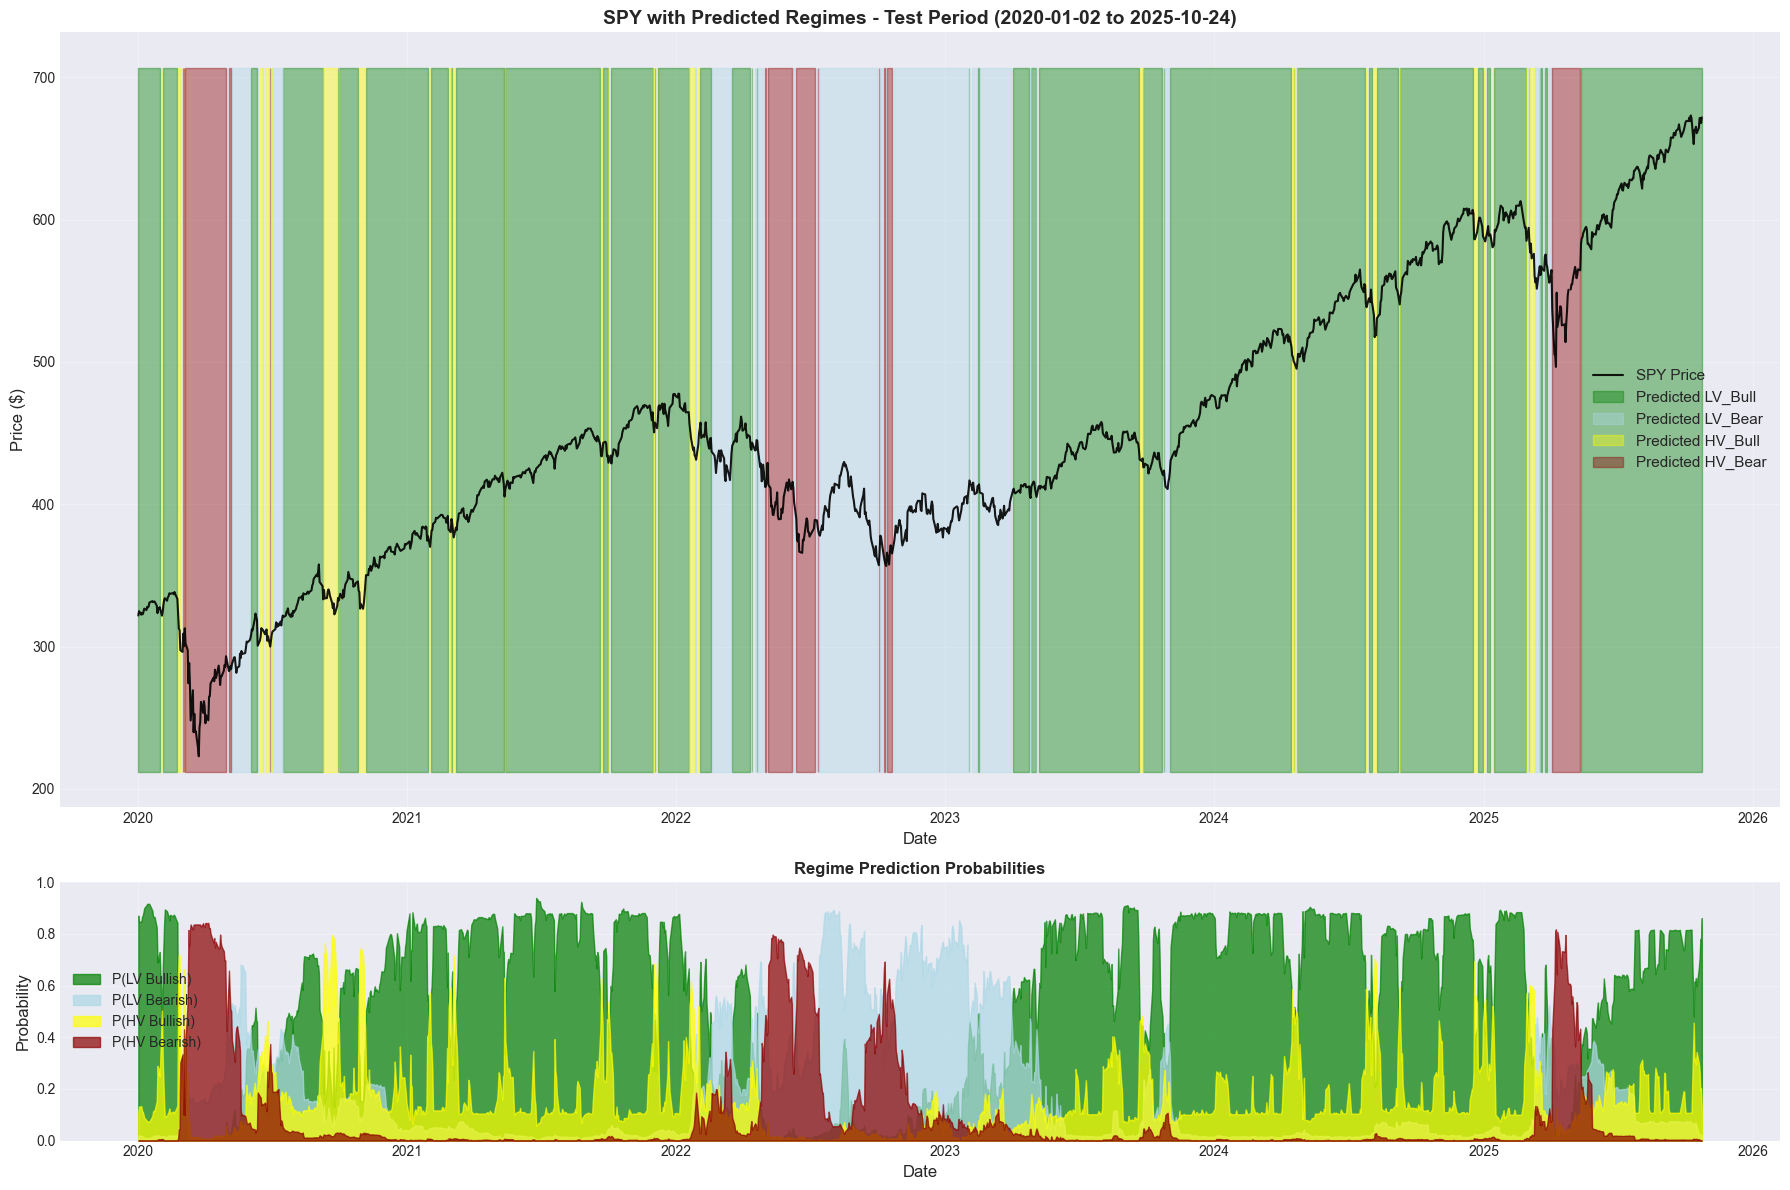


✓ Regime visualization complete!

PREDICTION SUMMARY FOR SPY
Test Period: 2020-01-02 to 2025-10-24
Total Trading Days: 1463

Price Performance:
  Start Price (open on 2020-01-02): $323.54
  End Price (close on 2025-10-24): $677.25
  Buy and Hold Return: 109.32%

Regime Prediction Statistics:
  LV Bullish: 994 days ( 67.9%) | Avg Prob: 0.557
  LV Bearish: 257 days ( 17.6%) | Avg Prob: 0.190
  HV Bullish:  86 days (  5.9%) | Avg Prob: 0.159
  HV Bearish: 126 days (  8.6%) | Avg Prob: 0.095

High Confidence Predictions (>70%): 831 days (56.8%)

Note: According to the contrarian strategy:
  - High P(Bullish) → SHORT signal (overbought)
  - High P(Bearish) → LONG signal (oversold)
  - High P(Other) → CLOSE position

KMRF MODEL TRAINING AND PREDICTION COMPLETE


In [11]:
# Get full price data and filter for test period
spy_price_full = kmrf_model.features[['open', 'close_lag1d']]\
    .join(raw_price_data[(asset_name, 'close')].rename('close'))
spy_price_test = spy_price_full.loc[test_predictions.index]

if spy_price_test is not None:
    # Create comprehensive visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), height_ratios=[3, 1])
    
    # === Price Plot with Regime Overlays ===
    # Plot SPY price
    ax1.plot(spy_price_test.index, spy_price_test['close_lag1d'], color='black', linewidth=1.5, 
             alpha=0.9, label='SPY Price', zorder=3)
    
    # Define colors and labels for regimes based on classification type
    if classification_type == 'original':
        colors = {0: 'green', 1: 'lightblue', 2: 'yellow', 3: 'darkred'}
        labels_dict = {0: 'LV_Bull', 1: 'LV_Bear', 2: 'HV_Bull', 3: 'HV_Bear'}
    else:
        colors = {1: 'green', 0: 'grey', -1: 'darkred'}
        labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    
    
    # Shade regime periods
    for regime in labels_dict:
        mask = predicted_regimes_series == regime
        if mask.any():
            ax1.fill_between(
                spy_price_test.index,
                spy_price_test['close_lag1d'].min() * 0.95,
                spy_price_test['close_lag1d'].max() * 1.05,
                where=mask,
                alpha=0.4,
                color=colors[regime],
                label=f'Predicted {labels_dict[regime]}',
                zorder=1
            )
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title(f'SPY with Predicted Regimes - Test Period ({test_predictions.index[0].date()} to {test_predictions.index[-1].date()})', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, zorder=2)
    
    # === Regime Probabilities ===
    # Plot regime probabilities
    # Handle different regime types based on classification
    if classification_type == 'original':
        # Original 4-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bull)'],
                     alpha=0.7, color='green', label='P(LV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bear)'],
                     alpha=0.7, color='lightblue', label='P(LV Bearish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bull)'],
                     alpha=0.7, color='yellow', label='P(HV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bear)'],
                     alpha=0.7, color='darkred', label='P(HV Bearish)')
    else:
        # Adapted 3-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bullish)'],
                     alpha=0.7, color='green', label='P(Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Other)'],
                     alpha=0.7, color='gray', label='P(Other)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bearish)'],
                     alpha=0.7, color='darkred', label='P(Bearish)')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Regime Prediction Probabilities', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Regime visualization complete!")
    
    # === Summary Statistics ===
    print(f"\n" + "="*60)
    print(f"PREDICTION SUMMARY FOR SPY")
    print(f"="*60)
    print(f"Test Period: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")
    print(f"Total Trading Days: {len(test_predictions)}")
    
    # Price performance during test period
    price_start = spy_price_test['open'].iloc[0]
    price_end = spy_price_test['close'].iloc[-1]
    total_return = (price_end - price_start) / price_start * 100
    
    print(f"\nPrice Performance:")
    print(f"  Start Price (open on {spy_price_test.index[0].date()}): ${price_start:.2f}")
    print(f"  End Price (close on {spy_price_test.index[-1].date()}): ${price_end:.2f}")
    print(f"  Buy and Hold Return: {total_return:.2f}%")
    
    # Regime statistics
    print(f"\nRegime Prediction Statistics:")
    for regime, name in regime_names.items():
        count = (predicted_regimes_series == regime).sum()
        pct = (count / len(predicted_regimes_series)) * 100
        avg_prob = test_predictions['P(' + labels_dict[regime] + ')'].mean()
        print(f"  {name:>8}: {count:>3} days ({pct:>5.1f}%) | Avg Prob: {avg_prob:.3f}")
    
    # High confidence predictions
    high_confidence = test_predictions.max(axis=1) > 0.7
    print(f"\nHigh Confidence Predictions (>70%): {high_confidence.sum()} days ({high_confidence.mean()*100:.1f}%)")
    
    print(f"\nNote: According to the contrarian strategy:")
    print(f"  - High P(Bullish) → SHORT signal (overbought)")
    print(f"  - High P(Bearish) → LONG signal (oversold)")
    print(f"  - High P(Other) → CLOSE position")

else:
    print("Error: Could not find SPY price data for visualization")

print("\n" + "="*80)
print("KMRF MODEL TRAINING AND PREDICTION COMPLETE")
print("="*80)

## Saving Model

In [12]:
kmrf_model.save_model(boruta_used=boruta_feature_selection)  # Saves with auto-generated name


Saving model to: saved_models/KMRF/original_labels/us_equity/KMRF_SPDR-S&P-500-ETF_20190101.pkl
✓ Model saved successfully


PosixPath('saved_models/KMRF/original_labels/us_equity/KMRF_SPDR-S&P-500-ETF_20190101.pkl')

## Loading Saved Model

In [13]:
# If loading a different model than the one that was just trained and saved,
#   --> uncomment, edit model path variables, and run this cell

# asset_name = 'SPDR S&P 500 ETF'
# asset_class = 'us_equity' # us_equity, int_equity, us_treasury, commodity

# classification_type = 'original'  # 'original' or 'adapted'
# boruta_feature_selection = True  # Whether Boruta feature selection was used

In [14]:
# If loading the model that was just trained and saved, run this cell
if boruta_feature_selection:
    model_path = f'saved_models/KMRF/{classification_type}_labels/{asset_class}/KMRF_{("-").join(asset_name.split())}_20190101_boruta.pkl'
else:
    model_path = f'saved_models/KMRF/{classification_type}_labels/{asset_class}/KMRF_{("-").join(asset_name.split())}_20190101.pkl'

loaded_kmrf = kmrf.KMRF.load_model(model_path)

loaded_kmrf

Loading model from: saved_models/KMRF/original_labels/us_equity/KMRF_SPDR-S&P-500-ETF_20190101.pkl
KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: adapted
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 to 2019-09-30
  Test start: 2020-01-01
  Random seed: 1010
✓ Model loaded successfully
  Asset class: us_equity
  Training end date: 20190101
  Features: all


KMRF('SPDR S&P 500 ETF', us_equity)

In [18]:
loaded_kmrf

KMRF('SPDR S&P 500 ETF', us_equity)